\*Doble click para ver comandos de LaTex*
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\had}[1]{  \frac{\ket{0}#1\ket{1}}{\sqrt{2}} } $

*Asegurate de tener instalado estas dependencias en tu noteboook*

In [1]:
%%capture
# -------------------------------------------------------------
# Instalamos dependencias y paquetes
# -------------------------------------------------------------

!pip install qiskit                         #Qiskit
!pip install qiskit-aer                     #simulador cuántico local
!pip install pylatexenc                     #renderiza latex dentro de gráficos
#!pip install qiskit-ibm-runtime            #Solo para ejecutar en hardware real

# Si tienes problemas para ejecutar luego de haber instalado, restaura la sesión: Runtime > Restart session

## Ejercicio 2.31 - Wong

Cálcula $Y^{51}H^{99}T^{36}Z^{25}\ket{0}$

**Sol.**

(a).
\begin{align*}
Y^{51}H^{99}T^{36}Z^{25}\ket{0} &= (Y^2)^{25}Y(H^2)^{49}H(T^4)^{9}(Z^2)^{12}Z\ket{0} \\
                                &= (I)^{25}Y(I)^{49}H(Z)^{9}(I)^{12}Z\ket{0} \\
                                &= YH(Z)^{9}Z\ket{0} \\
                                &= YH(Z^2)^{10}\ket{0} \\
                                &= YH(I)^{10}\ket{0} \\
                                &= YH\ket{0} \\
                                &= Y\ket{+} \\
                                &= Y\had{+} \\
                                &= \frac{1}{\sqrt{2}}\left(Y\ket{0}+Y\ket{1}\right) \\
                                &= \frac{1}{\sqrt{2}}\left(i\ket{1}-i\ket{0}\right) \\
                                &= -i\ket{-} = \myvector{-\frac{i}{\sqrt{2}} \\ \frac{i}{\sqrt{2}}}
\end{align*}


## 3. Verificación con Qiskit

Solo con fines de verificación, construiremos en Qiskit una nueva compuerta $U$ que represente la operación completa $Y^{51}H^{99}T^{36}Z^{25}\ket{0}$. Aunque esta secuencia parece compleja, las potencias de las puertas tienen periodicidad (por ejemplo, $Y^2 = I$ y $H^2 = I$), por lo que el circuito puede simplificarse a: $Y^{51}H^{99}T^{36}Z^{25}\ket{0} = Y\ket{+}.
$

Por lo tanto, la compuerta $U$ será utilizada únicamente para confirmar este resultado.









In [39]:
# -------------------------------------------------------------
# Ejercicio 2.31 Wong
# -------------------------------------------------------------
from qiskit import QuantumCircuit
from qiskit.circuit.library import YGate, HGate, TGate, ZGate
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
import numpy as np

# Obtenemos la representación matricial de Y, H, T y Z
Y = Operator(YGate()).data
H = Operator(HGate()).data
T = Operator(TGate()).data
Z = Operator(ZGate()).data

Y51 = np.linalg.matrix_power(Y, 51)
H99 = np.linalg.matrix_power(H, 99)
T36 = np.linalg.matrix_power(T, 36)
Z25 = np.linalg.matrix_power(Z, 25)


#Convertimos la matriz en un gate

U = Operator(Y51@H99@T36@Z25)

# Creamos un circuito de un qubit
qc = QuantumCircuit(1)

#Añadimos una compuerta U
qc.append(U, [0])

#Evaluamos el estado del qubit
state = Statevector.from_instruction(qc)

#Visualizamos el estado
print('Estado del qubit: ', state.data)


Estado del qubit:  [0.-0.70710678j 0.+0.70710678j]


Note que el resultado `[0.-0.70710678j 0.+0.70710678j]` es  $\myvector{-\frac{i}{\sqrt{2}} \\ \frac{i}{\sqrt{2}}}$ mismo resultado que obtuvimos en nuestro desarrollo algebraico.

## 4. Visualización


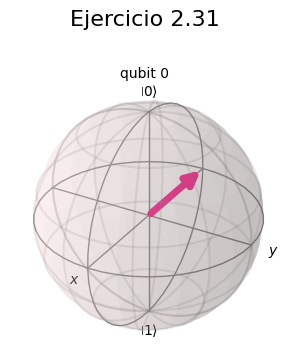

In [41]:
# Visualizamos estados en la esfera de Bloch
from qiskit.visualization import plot_bloch_multivector
plot_bloch_multivector(state, title='Ejercicio 2.31', figsize=(3, 3))

## 5. Conclusión

Este ejercicio muestra cómo aprovechar la periodicidad de las compuertas permite reducir circuitos sin alterar el resultado final. Esta reducción es clave tanto en simulación como en hardware real para ejecutar algoritmos cuánticos de manera más eficiente.

## 5. Referencias
### Referencias
1. D. McMahon. Quantum Computing Explained. IEEE Press. Wiley, 2008.
2. Thomas G. Wong. Introduction to Classical and Quantum Computing. University of Texas Rio
Grande Valley, 2021.
